## CUSTOMER SEGMENTATION USING K-MEANS

## “Key Questions Answered”

1) Can customers be segmented based on behavioral patterns?
2) Which customer segments show the highest churn risk?
3) How can the bank act differently for each segment?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df=pd.read_csv('BankChurners.csv')
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [4]:
#Checking null values
df.isnull().sum()

CLIENTNUM                                                                                                                             0
Attrition_Flag                                                                                                                        0
Customer_Age                                                                                                                          0
Gender                                                                                                                                0
Dependent_count                                                                                                                       0
Education_Level                                                                                                                       0
Marital_Status                                                                                                                        0
Income_Category                                 

In [5]:
#check duplicate records
df.duplicated().sum()

0

In [6]:
#Encode categorical feature Gender
df['Gender']=df['Gender'].map({'M':0,'F':1})

In [7]:
#Numerical data
df.describe()

,CLIENTNUM,Customer_Age,Gender,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,0.529081,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894,0.159997,0.840003
std,3.690378e+07,8.016814,0.499178,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691,0.365301,0.365301
min,7.080821e+08,26.000000,0.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000,0.000008,0.000420
25%,7.130368e+08,41.000000,0.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000,0.000099,0.999660
50%,7.179264e+08,46.000000,1.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000,0.000181,0.999820
75%,7.731435e+08,52.000000,1.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000,0.000337,0.999900
max,8.283431e+08,73.000000,1.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000,0.999580,0.999990


In [8]:
df.head(10)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,0,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,1,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,0,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,1,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,0,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998
5,713061558,Existing Customer,44,0,2,Graduate,Married,$40K - $60K,Blue,36,...,4010.0,1247,2763.0,1.376,1088,24,0.846,0.311,0.000055,0.99994
6,810347208,Existing Customer,51,0,4,Unknown,Married,$120K +,Gold,46,...,34516.0,2264,32252.0,1.975,1330,31,0.722,0.066,0.000123,0.99988
7,818906208,Existing Customer,32,0,0,High School,Unknown,$60K - $80K,Silver,27,...,29081.0,1396,27685.0,2.204,1538,36,0.714,0.048,0.000086,0.99991
8,710930508,Existing Customer,37,0,3,Uneducated,Single,$60K - $80K,Blue,36,...,22352.0,2517,19835.0,3.355,1350,24,1.182,0.113,0.000045,0.99996
9,719661558,Existing Customer,48,0,2,Graduate,Single,$80K - $120K,Blue,36,...,11656.0,1677,9979.0,1.524,1441,32,0.882,0.144,0.000303,0.99970


In this dataset we have Financial , behavioral and demographic features:
1) Financial features:
-- Credit_Limit
-- Avg_Open_To_Buy
-- Avg_Utilization_Ratio
2) Behavioral features:
-- Total_Trans_Amt
-- Total_Trans_Ct
-- Total_Ct_Chng_Q4_Q1
-- Total_Amt_Chng_Q4_Q1
3) Deomographic features:
-- Customer_Age
-- Gender
-- Dependent_count
-- Education_Level
-- Income_Category

In [9]:
df.drop(['Attrition_Flag'],axis=1,inplace=True)


In [10]:
df.drop(['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1'],axis=1,inplace=True)
df.drop(['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],axis=1,inplace=True)

Clustering is an unsupervised technique, so target labels like Attrition_Flag and model-derived features were removed to prevent data leakage and ensure unbiased customer segmentation.


In [11]:
df.head(2)

,CLIENTNUM,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,45,0,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,49,1,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105


In [12]:
##Outlier detection
numeric_features=df.select_dtypes(include=[np.number])


In [13]:
#function to detect outliers
def detect_outliers(data):
    outlier_summary={}
    for col in data.columns:
        Q1=data[col].quantile(0.25)
        Q3=data[col].quantile(0.75)
        IQR=Q3-Q1
        lower_bound=Q1-1.5*IQR
        upper_bound=Q3+1.5*IQR
        outliers=data[(data[col]<lower_bound)| (data[col]>upper_bound)]
        outlier_summary[col]=len(outliers)

    return outlier_summary



In [14]:
outlier_count=detect_outliers(numeric_features)
outlier_count

{'CLIENTNUM': 0,
 'Customer_Age': 2,
 'Gender': 0,
 'Dependent_count': 0,
 'Months_on_book': 386,
 'Total_Relationship_Count': 0,
 'Months_Inactive_12_mon': 331,
 'Contacts_Count_12_mon': 629,
 'Credit_Limit': 984,
 'Total_Revolving_Bal': 0,
 'Avg_Open_To_Buy': 963,
 'Total_Amt_Chng_Q4_Q1': 396,
 'Total_Trans_Amt': 896,
 'Total_Trans_Ct': 2,
 'Total_Ct_Chng_Q4_Q1': 394,
 'Avg_Utilization_Ratio': 0}

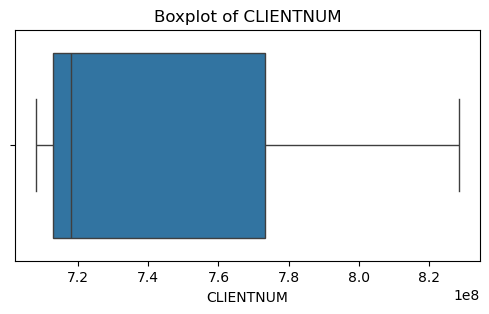

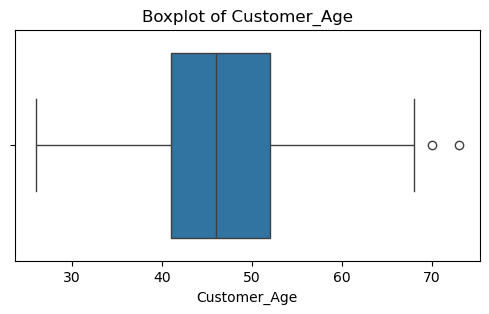

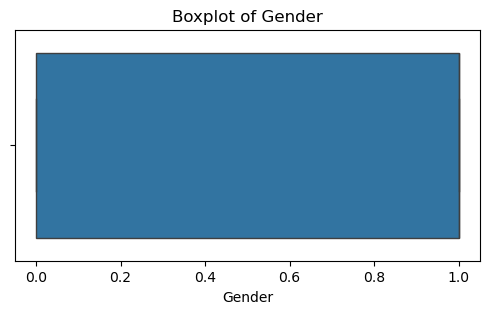

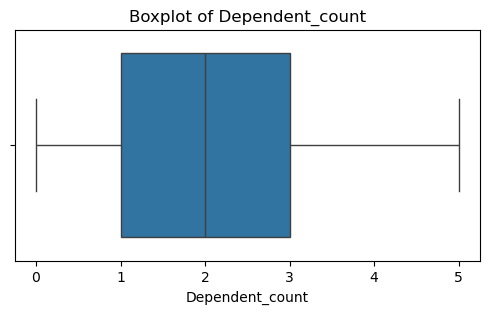

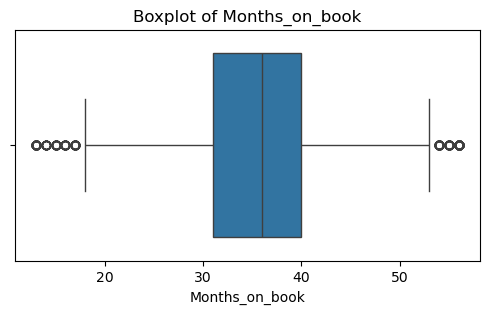

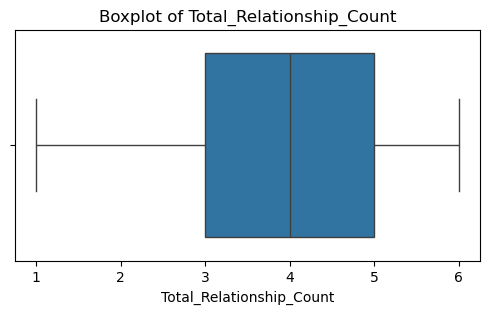

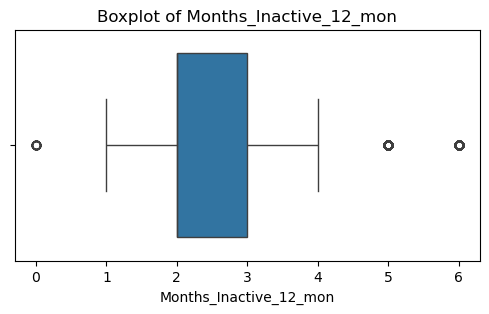

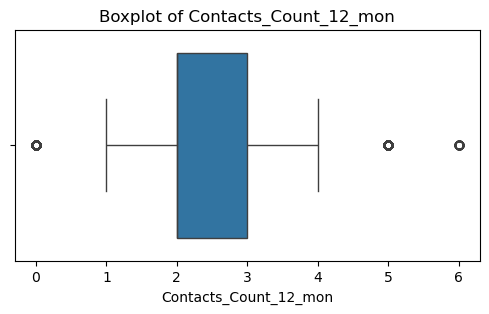

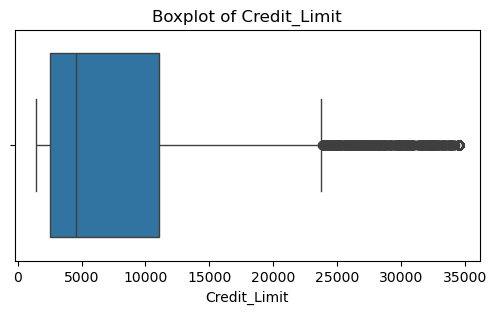

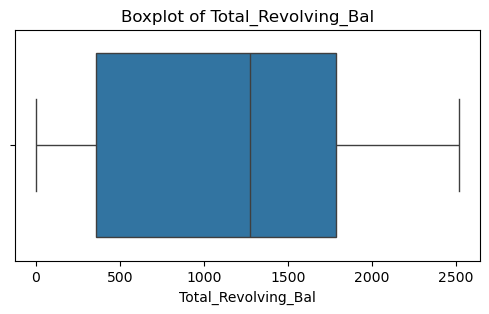

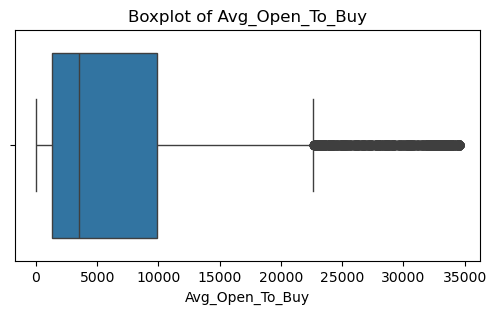

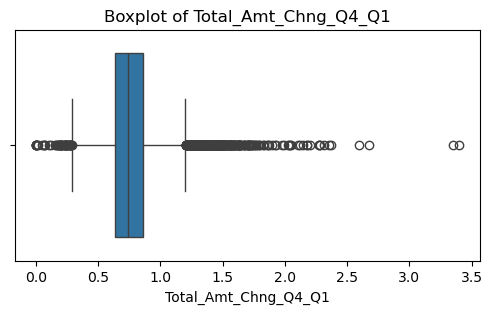

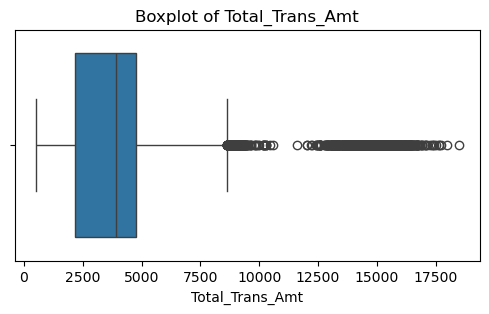

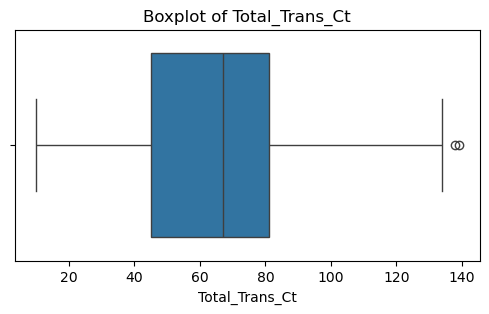

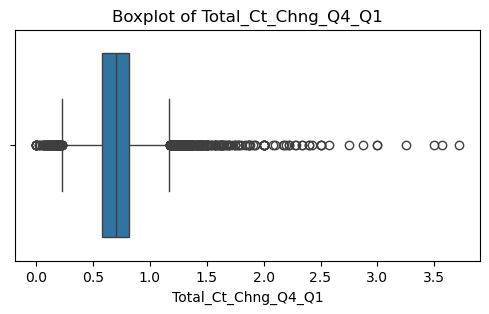

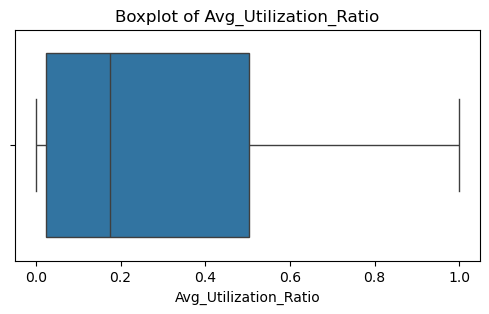

In [15]:
for col in numeric_features.columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=numeric_features[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

## Columns with moderate outliers 
These represent real customer behavior:
- Credit_Limit (984)
- Avg_Open_To_Buy (963)
- Total_Trans_Amt (896)
 These are:
- High-value customers
- Premium card holders

## We need to cap columns that will affect distance calculation strongly:
- Months_on_book (386)
- Months_Inactive_12_mon (331)
- Contacts_Count_12_mon (629)
- Total_Amt_Chng_Q4_Q1 (396)
- Total_Ct_Chng_Q4_Q1 (394)

In [16]:
##Winsorization--> Capping
def cap_outliers_iqr(df):
    df_capped = df.copy()

    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df_capped[col] = df[col].clip(lower, upper)

    return df_capped


In [17]:
numeric_features_capped = cap_outliers_iqr(numeric_features)


In [18]:
detect_outliers(numeric_features_capped)


{'CLIENTNUM': 0,
 'Customer_Age': 0,
 'Gender': 0,
 'Dependent_count': 0,
 'Months_on_book': 0,
 'Total_Relationship_Count': 0,
 'Months_Inactive_12_mon': 0,
 'Contacts_Count_12_mon': 0,
 'Credit_Limit': 0,
 'Total_Revolving_Bal': 0,
 'Avg_Open_To_Buy': 0,
 'Total_Amt_Chng_Q4_Q1': 0,
 'Total_Trans_Amt': 0,
 'Total_Trans_Ct': 0,
 'Total_Ct_Chng_Q4_Q1': 0,
 'Avg_Utilization_Ratio': 0}

Since extreme values in banking data often represent genuine high-value customers, I applied IQR-based capping instead of removal to control their influence while preserving customer diversity.

In [19]:
df.head()

,CLIENTNUM,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,45,0,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,49,1,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,51,0,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,40,1,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,40,0,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [20]:
##Feature Scaling (Standardization)
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [21]:
scaled_features=scaler.fit_transform(numeric_features_capped)

In [22]:
scaled_df=pd.DataFrame(scaled_features,columns=numeric_features_capped.columns)

In [23]:
scaled_df.describe()

,CLIENTNUM,Customer_Age,Gender,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.012700e+04,1.012700e+04,1.012700e+04,1.012700e+04,1.012700e+04,1.012700e+04,1.012700e+04,1.012700e+04,1.012700e+04,1.012700e+04,1.012700e+04,1.012700e+04,1.012700e+04,1.012700e+04,1.012700e+04,1.012700e+04
mean,-6.398884e-16,-8.279258e-17,-1.459395e-16,-7.577626e-17,-2.329418e-16,-4.490445e-17,-4.350118e-17,-8.980890e-17,2.245222e-17,-7.016320e-17,-2.020700e-16,5.613056e-18,-4.490445e-17,-1.347133e-16,-1.347133e-16,-7.296973e-17
std,1.000049e+00,1.000049e+00,1.000049e+00,1.000049e+00,1.000049e+00,1.000049e+00,1.000049e+00,1.000049e+00,1.000049e+00,1.000049e+00,1.000049e+00,1.000049e+00,1.000049e+00,1.000049e+00,1.000049e+00,1.000049e+00
min,-8.426523e-01,-2.536030e+00,-1.059956e+00,-1.806378e+00,-2.372974e+00,-1.809512e+00,-1.951508e+00,-1.909199e+00,-8.929259e-01,-1.426858e+00,-9.300157e-01,-2.505714e+00,-1.590456e+00,-2.337437e+00,-2.411253e+00,-9.971550e-01
25%,-7.083861e-01,-6.644550e-01,-1.059956e+00,-1.036462e+00,-6.362179e-01,-5.227845e-01,-3.390859e-01,-4.468307e-01,-7.381883e-01,-9.863389e-01,-7.470632e-01,-6.523875e-01,-8.293074e-01,-8.461270e-01,-6.160640e-01,-9.137243e-01
50%,-5.758840e-01,-4.059668e-02,9.434357e-01,-2.665471e-01,7.025049e-03,1.205790e-01,-3.390859e-01,-4.468307e-01,-4.618861e-01,1.388875e-01,-4.494798e-01,-8.338388e-02,-2.282732e-02,9.126805e-02,-7.525360e-03,-3.587287e-01
75%,9.204369e-01,7.080333e-01,9.434357e-01,5.033681e-01,5.216194e-01,7.639426e-01,7.358625e-01,5.280813e-01,4.413617e-01,7.622408e-01,4.344792e-01,5.831633e-01,3.666514e-01,6.877922e-01,5.807286e-01,8.274384e-01
max,2.416280e+00,2.766766e+00,9.434357e-01,2.043199e+00,2.258375e+00,1.407306e+00,2.348285e+00,1.990449e+00,2.210687e+00,1.661686e+00,2.206793e+00,2.436489e+00,2.160590e+00,2.988671e+00,2.375918e+00,2.626640e+00


After treating outliers, I standardized numeric features using StandardScaler to ensure equal contribution of all variables during distance-based clustering.

In [24]:
##Elbow Method
from sklearn.cluster import KMeans
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)
    

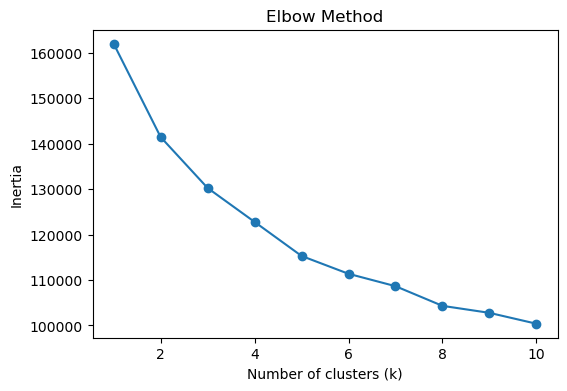

In [25]:
plt.figure(figsize=(6,4))
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

The elbow plot shows a clear bend at k=4 fter which the decrease in inertia becomes marginal.

In [26]:
##Silhoette score
from sklearn.metrics import silhouette_score
silhouette_scores=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(scaled_df)
    score=silhouette_score(scaled_df,labels)
    silhouette_scores.append(score)

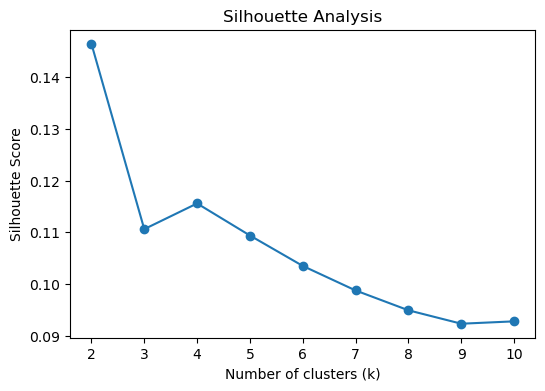

In [27]:
plt.figure(figsize=(6,4))
plt.plot(range(2,11), silhouette_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.show()

Although the silhouette score is highest at k = 2, it resulted in overly broad clusters. Based on the elbow method and the need for meaningful business segmentation, k = 4 is selected as the optimal balance between cohesion and interpretability.


In [28]:
##K-Means implementation
kmeans=KMeans(n_clusters=4,init='k-means++',random_state=42)

In [29]:
cluster_labels=kmeans.fit_predict(scaled_df)


In [30]:
##adding cluster labels to data
scaled_df['Cluster']=cluster_labels
df['Cluster']=cluster_labels

In [31]:
scaled_df['Cluster'].value_counts()


Cluster
0    4060
3    2786
2    1868
1    1413
Name: count, dtype: int64

In [32]:
##Cluster profiling and interpretation
cluster_profile=df.groupby('Cluster').mean(numeric_only=True)
cluster_profile

,CLIENTNUM,Customer_Age,Gender,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
Cluster,,,,,,,,,,,,,,,,
0,7.397014e+08,46.306897,0.692365,2.303695,35.783251,4.116010,2.309360,2.376355,3515.169803,1671.797044,1843.372759,0.785068,3553.188177,63.231527,0.753004,0.552739
1,7.368016e+08,45.405520,0.360934,2.417551,35.210191,2.130219,2.210899,2.188960,14552.334961,1323.026893,13229.308068,0.779177,11322.597311,98.423213,0.728068,0.158805
2,7.417070e+08,46.695931,0.114026,2.498394,36.330300,4.309957,2.344218,2.595824,21186.799251,1172.542827,20014.256424,0.773473,2928.445396,55.106531,0.723881,0.067528
3,7.379234e+08,46.572505,0.654702,2.269921,36.234745,3.890165,2.451543,2.611271,4667.916511,333.300431,4334.616080,0.704492,3124.577172,56.745513,0.636939,0.067908


In [33]:
df.groupby('Cluster')['Income_Category'].value_counts(normalize=True)


Cluster  Income_Category
0        Less than $40K     0.492118
         $40K - $60K        0.208374
         Unknown            0.102217
         $60K - $80K        0.097783
         $80K - $120K       0.072660
         $120K +            0.026847
1        Less than $40K     0.249823
         $80K - $120K       0.211607
         $60K - $80K        0.174805
         $40K - $60K        0.170559
         $120K +            0.107573
         Unknown            0.085633
2        $80K - $120K       0.373662
         $60K - $80K        0.228051
         $120K +            0.208779
         Unknown            0.095824
         $40K - $60K        0.074946
         Less than $40K     0.018737
3        Less than $40K     0.421752
         $40K - $60K        0.202082
         Unknown            0.142498
         $60K - $80K        0.119167
         $80K - $120K       0.087222
         $120K +            0.027279
Name: proportion, dtype: float64

## Initial Cluster Insights
1. Cluster 0:
- Has lowest average Credit limit.
- Has highest Average Utilization ratio,indicating heavy reliance on credit.
- Dominated by low-income customers.
2. Cluster 1:
- Moderate credit limit and utilization.
- Has highest  transaction count and transaction amount.
- Represents the most engaged customer segment.
3. Cluster 2:
- Has highest Credit limit.
- Very low utilization ratio.
- High-income dominant cluster with conservative spending behavior.
4. Cluster 3:
- Low credit utilization and revolving balance.
- Higher proportion of low-income customers.
- Likely inactive or minimally engaged users.



  ## Cluster labels       	                
-  Cluster 0	                - Credit-Dependent Loyal Customers
-  Cluster 1	                - Highly Active Core Customers
-  Cluster 2	                - Premium Low-Risk Customers
-  Cluster 3	                - High Churn Risk Customer

In [34]:
##Adding attrition flag back for churn analysis
df_raw = pd.read_csv('BankChurners.csv')


In [35]:
df['Attrition_Flag'] = df_raw['Attrition_Flag'].values


In [36]:
df['Attrition_Flag'].value_counts()


Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

In [37]:
df['Churn']=df['Attrition_Flag'].map({'Attrited Customer':1,'Existing Customer':0})

In [38]:
churn_by_cluster=df.groupby('Cluster')['Churn'].mean()
churn_by_cluster

Cluster
0    0.076355
1    0.102619
2    0.139722
3    0.326992
Name: Churn, dtype: float64

In [39]:
df.groupby('Cluster')['Churn'].value_counts(normalize=True)


Cluster  Churn
0        0        0.923645
         1        0.076355
1        0        0.897381
         1        0.102619
2        0        0.860278
         1        0.139722
3        0        0.673008
         1        0.326992
Name: proportion, dtype: float64

After clustering, I validated the segments by analyzing churn rates across clusters and found that the low-engagement customer cluster exhibited a substantially higher churn rate, while highly active and premium customer clusters showed strong retention.

In [40]:
##PCA visualization
X_pca_input=scaled_df.drop(columns=['Cluster'])

In [41]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2,random_state=42)
pca_components=pca.fit_transform(X_pca_input)

In [42]:
pca_df=pd.DataFrame(pca_components,columns=['PC1','PC2'])
pca_df['Cluster']=scaled_df['Cluster'].values

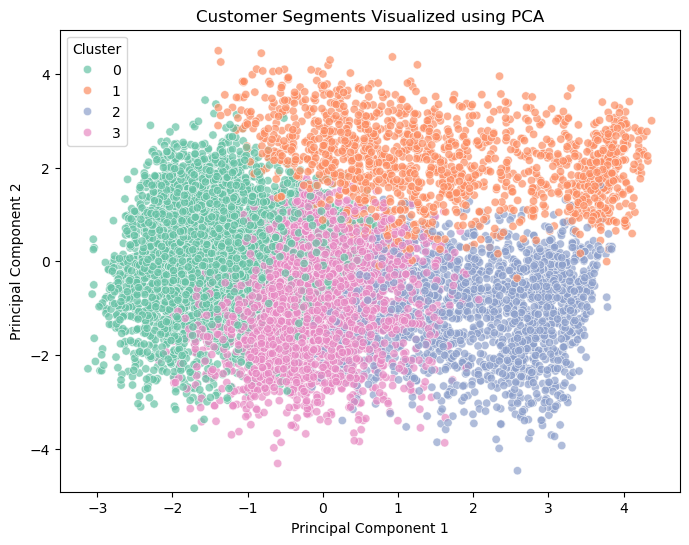

In [43]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df,x='PC1',y='PC2',hue='Cluster',palette='Set2',alpha=0.7)
plt.title('Customer Segments Visualized using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

## PCA Cluster Visualization Insights

- The PCA plot shows that customer segments form distinct groupings with some overlap, which is expected in real-world behavioral data.
- Certain clusters appear more compact, indicating consistent usage patterns, while others are more dispersed, suggesting varied customer behavior within those segments.
- The presence of partial overlap reflects transitional customers whose behavior lies between segments, highlighting the continuous nature of customer engagement.
- Overall, the PCA visualization supports the interpretability of the clustering results and complements the behavioral and churn-based analysis.

# Limitations and Future Work

- Clustering performance depends on selected features and scaling.
- PCA was used only for visualization, not dimensionality reduction.
- Future work could include DBSCAN or RFM-based clustering.